<a href="https://colab.research.google.com/github/sevcikoleksandr233/machine-learning/blob/main/%D0%A8%D0%B5%D0%B2%D1%87%D0%B8%D0%BA_%D0%BF%D1%80_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


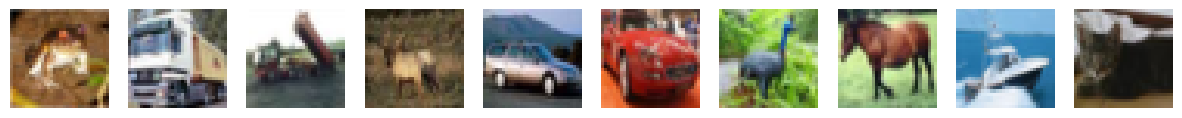

In [1]:
'''Завдання 1. Модель згорткової нейронної мережі для датасета CIFAR-10
Завантаження датасета та виведення перших 10 зображень:'''
import tensorflow as tf
import matplotlib.pyplot as plt

# Завантаження датасета CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Виведення перших 10 зображень
fig, axes = plt.subplots(1, 10, figsize=(15,15))
for i in range(10):
    axes[i].imshow(x_train[i])
    axes[i].axis('off')
plt.show()


In [2]:
'''Підготовка даних:'''
# Нормалізація зображень
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Перетворення міток на категоріальні змінні
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


In [3]:
'''Архітектура моделі:'''
from tensorflow.keras import layers, models

# Створення моделі
model = models.Sequential()

# Згорткові шари
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Повнозв’язні шари
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Компіляція моделі
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
'''Кол-бекі (рання зупинка і зменшення швидкості навчання):'''
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)

callbacks = [early_stopping, reduce_lr]


In [5]:
'''Виведення summary:'''
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3179 - loss: 1.8534 - val_accuracy: 0.5052 - val_loss: 1.3565 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5431 - loss: 1.2792 - val_accuracy: 0.5863 - val_loss: 1.1781 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6162 - loss: 1.0947 - val_accuracy: 0.6229 - val_loss: 1.0647 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6534 - loss: 0.9858 - val_accuracy: 0.6272 - val_loss: 1.0740 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6868 - loss: 0.9051 - val_accuracy: 0.6353 - val_loss: 1.0450 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7019 - loss: 0.8645 - val_accuracy: 0.6833 - val_loss: 0.9008 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7243 - loss: 0.7961 -

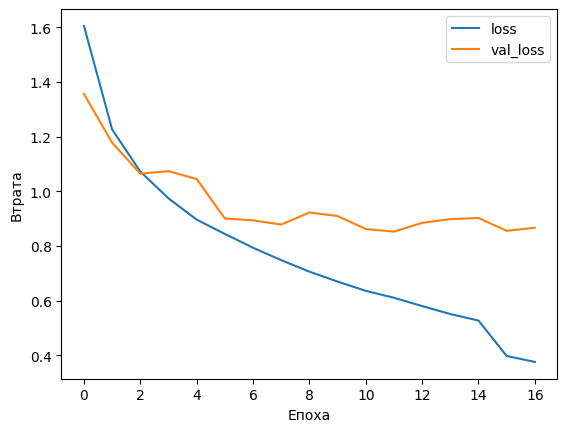

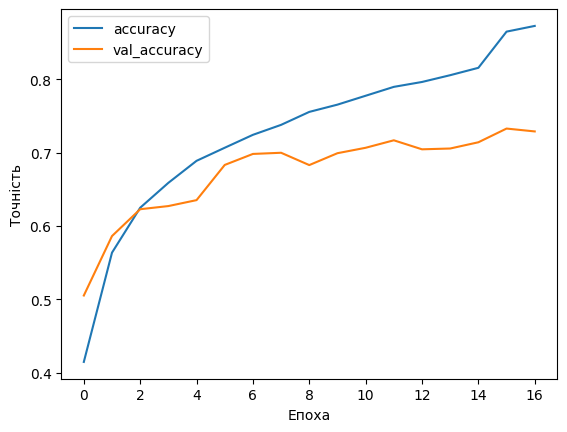

In [6]:
'''Навчання моделі і побудова графіків:'''
history = model.fit(x_train, y_train, epochs=50, batch_size=64,
                    validation_data=(x_test, y_test),
                    callbacks=callbacks)

# Побудова графіків
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Епоха')
plt.ylabel('Втрата')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.show()


In [7]:
'''Класифікаційний звіт:'''
from sklearn.metrics import classification_report

# Прогнозування
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# Класифікаційний звіт
print(classification_report(y_true, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1000
           1       0.83      0.85      0.84      1000
           2       0.62      0.65      0.63      1000
           3       0.59      0.50      0.54      1000
           4       0.70      0.67      0.68      1000
           5       0.65      0.61      0.63      1000
           6       0.77      0.79      0.78      1000
           7       0.76      0.77      0.77      1000
           8       0.80      0.84      0.82      1000
           9       0.81      0.82      0.82      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



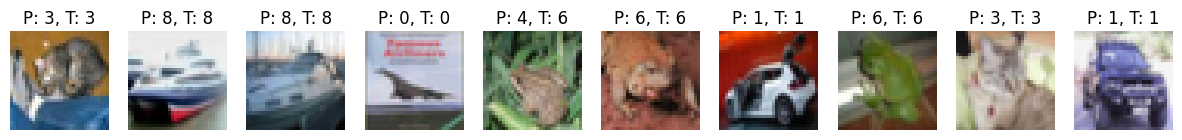

In [8]:
'''Візуалізація розпізнавання:'''
import numpy as np

# Показати перші 10 прогнозів
fig, axes = plt.subplots(1, 10, figsize=(15, 15))
for i in range(10):
    axes[i].imshow(x_test[i])
    axes[i].axis('off')
    pred_label = y_pred_classes[i]
    true_label = y_true[i]
    axes[i].set_title(f'P: {pred_label}, T: {true_label}')
plt.show()


In [9]:
'''Завдання 2. Попередньо навчена модель VGG16
Побудова моделі VGG16 та тонке налаштування:'''
from tensorflow.keras.applications import VGG16

# Завантаження попередньо навченої моделі VGG16
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Заморожування всіх шарів базової моделі
vgg_base.trainable = False

# Додавання шарів зверху
model_vgg = models.Sequential()
model_vgg.add(vgg_base)
model_vgg.add(layers.Flatten())
model_vgg.add(layers.Dense(64, activation='relu'))
model_vgg.add(layers.Dense(10, activation='softmax'))

# Компіляція моделі
model_vgg.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
'''Навчання та кол-бекі:'''
history_vgg = model_vgg.fit(x_train, y_train, epochs=50, batch_size=64,
                            validation_data=(x_test, y_test),
                            callbacks=callbacks)

# Виведення summary
model_vgg.summary()


Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.4238 - loss: 1.6523 - val_accuracy: 0.5426 - val_loss: 1.3099 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5684 - loss: 1.2473 - val_accuracy: 0.5687 - val_loss: 1.2347 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5893 - loss: 1.1789 - val_accuracy: 0.5786 - val_loss: 1.2119 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6002 - loss: 1.1468 - val_accuracy: 0.5808 - val_loss: 1.1947 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6064 - loss: 1.1196 - val_accuracy: 0.5861 - val_loss: 1.1775 - learning_rate: 0.0010


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 1, 1, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,815,136 (56.52 MB)

 Trainable params: 33,482 (130.79 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 66,966 (261.59 KB)

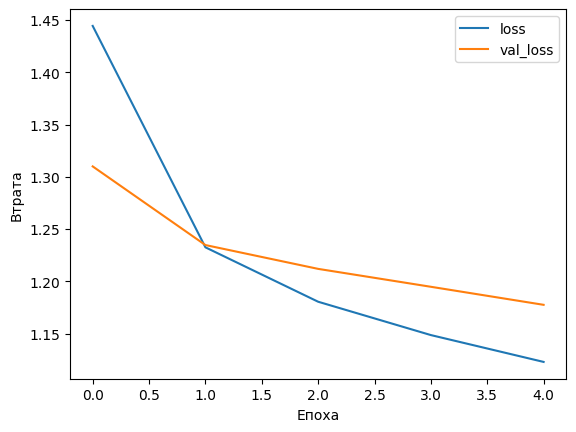

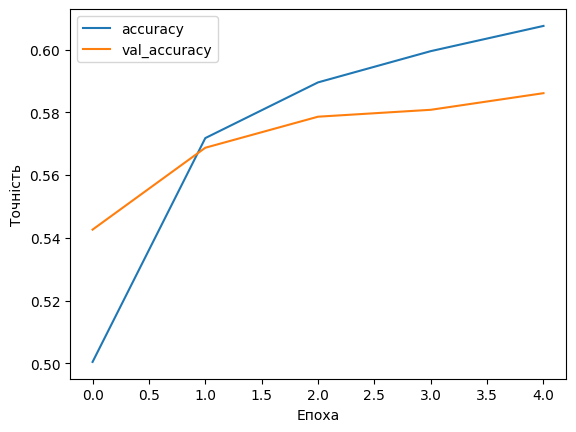

In [11]:
'''Графіки функції втрат і точності'''
# Побудова графіків втрат
plt.plot(history_vgg.history['loss'], label='loss')
plt.plot(history_vgg.history['val_loss'], label='val_loss')
plt.xlabel('Епоха')
plt.ylabel('Втрата')
plt.legend()
plt.show()

# Побудова графіків точності
plt.plot(history_vgg.history['accuracy'], label='accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.show()


In [12]:
'''Класифікаційний звіт'''
# Прогнозування
y_pred_vgg = model_vgg.predict(x_test)
y_pred_vgg_classes = y_pred_vgg.argmax(axis=1)
y_true_vgg = y_test.argmax(axis=1)

# Класифікаційний звіт
print(classification_report(y_true_vgg, y_pred_vgg_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
              precision    recall  f1-score   support

           0       0.65      0.69      0.67      1000
           1       0.61      0.71      0.65      1000
           2       0.51      0.46      0.49      1000
           3       0.39      0.51      0.44      1000
           4       0.55      0.49      0.52      1000
           5       0.63      0.43      0.51      1000
           6       0.60      0.68      0.64      1000
           7       0.61      0.70      0.65      1000
           8       0.73      0.67      0.70      1000
           9       0.66      0.52      0.58      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.59     10000
weighted avg       0.59      0.59      0.59     10000



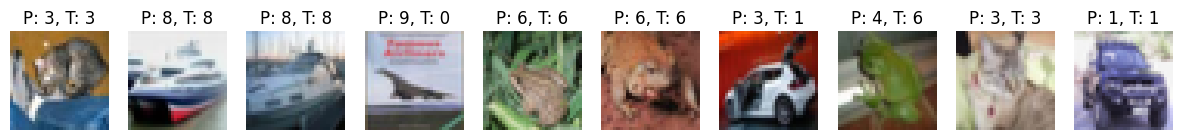

In [13]:
'''та візуалізація'''
# Показати перші 10 прогнозів VGG16
fig, axes = plt.subplots(1, 10, figsize=(15, 15))
for i in range(10):
    axes[i].imshow(x_test[i])
    axes[i].axis('off')
    pred_label = y_pred_vgg_classes[i]
    true_label = y_true_vgg[i]
    axes[i].set_title(f'P: {pred_label}, T: {true_label}')
plt.show()


In [ ]:
'''У цій лабораторній роботі була створена згорткова нейронна мережа для
класифікації зображень з датасета CIFAR-10. Модель включала згорткові,
пулінгові та повнозв’язні шари. Нормалізація даних та використання кол-беків,
таких як рання зупинка і зменшення швидкості навчання, допомогли стабілізувати
процес та уникнути перенавчання. Аналіз результатів через графіки втрат і
точності показав ефективність моделі, а класифікаційний звіт дав уявлення про
точність для кожного класу.

Було також використано попередньо навчену модель VGG16 з тонким налаштуванням,
що забезпечило високу точність класифікації. Робота дозволила зрозуміти
принципи роботи згорткових мереж та їх оптимізацію для вирішення задач
класифікації зображень.'''